# Plot response to Q2.1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

0.1678571731032958
0.1875118442330733
0.095977955538754
0.1252367272338721
0.2201106670052567
0.1048862438186139


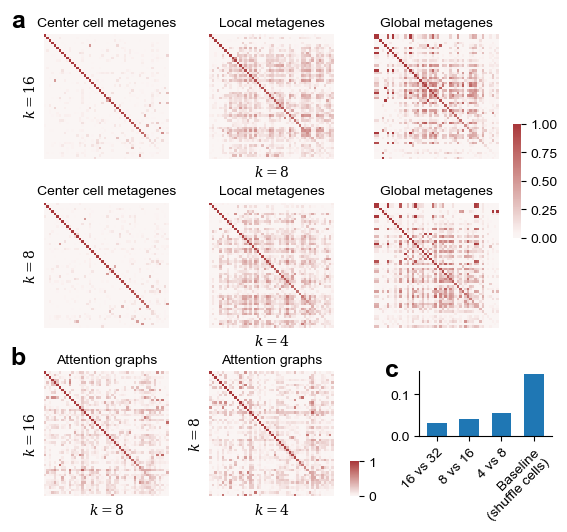

In [15]:
fig = plt.figure(figsize=(6.5, 6))
gs = GridSpec(3, 4, height_ratios=[2, 2, 2], width_ratios=[2.13, 2.13, 2.13, 0.11], hspace=.35, wspace=.0, figure=fig)
axes = ([fig.add_subplot(gs[0, i]) for i in range(3)] + 
        [fig.add_subplot(gs[:2, 3])] +
        [fig.add_subplot(gs[1, i]) for i in range(3)] + 
        [fig.add_subplot(gs[2, i]) for i in range(2)] +
        [fig.add_subplot(gs[2, 3])] +
        [fig.add_subplot(gs[2, 2])])

cbar_ax = axes[3]
cbar_ax2 = axes[9]

############################
ax = axes[-1]
p4_df = pd.read_csv('saved_results/Ex2_mouse_brain_knn_neigh_comp_rmse.csv', index_col=0)
p4_df.index = ['4 vs 8', '8 vs 16', '16 vs 32', 'Baseline\n(shuffle cells)']
p4_df.iloc[[2, 1, 0, -1]].plot(kind='bar', legend=False, ax=ax, width=0.6)

# ax.axvline((baseline4 + baseline8 + baseline16 + baseline32) / 4, color='C1', linestyle='--', label='Baseline\n(shuffle all cells)   ')
# ax.text(0.055, -0.15, 'Baseline: shuffle all cells.')
# ax.legend(frameon=False, fontsize=8, loc='upper right')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=10)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

# ax.set_xlabel('RMSE between neighborhood compositions', fontsize=10)
# ax.set_ylabel('$k$ in $k$-NN', fontsize=10)

ax_position = ax.get_position()
ax_position.y0 += 0.1
ax_position.x1 += 0.05
ax_position.x0 += 0.1
ax.set_position(ax_position)

############################

cutoff = int(50 * .9 - 1)

ax = axes[2]
corr_df = pd.read_csv('saved_results/mmbrain_g_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Global metagenes', fontsize=10)
# ax.set_xlabel('$k=8$\n', fontsize=10)
# ax.set_ylabel('$k=16$', fontsize=10)
print(corr_df.iloc[cutoff, cutoff])
############################
ax = axes[1]
corr_df = pd.read_csv('saved_results/mmbrain_k_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Local metagenes', fontsize=10)
ax.set_xlabel('$k=8$', fontsize=10)
# ax.set_ylabel('$k=16$', fontsize=10)
print(corr_df.iloc[cutoff, cutoff])
############################
ax = axes[0]
corr_df = pd.read_csv('saved_results/mmbrain_q_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
# ax.set_xlabel('$k=8$\n', fontsize=10)
ax.set_ylabel('$k=16$', fontsize=10)
ax.set_title('Center cell metagenes', fontsize=10)
print(corr_df.iloc[cutoff, cutoff])
############################
ax = axes[6]
corr_df = pd.read_csv('saved_results/mmbrain_g_4_8_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Global metagenes', fontsize=10)
print(corr_df.iloc[cutoff, cutoff])
############################
ax = axes[5]
corr_df = pd.read_csv('saved_results/mmbrain_k_4_8_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Local metagenes', fontsize=10)
ax.set_xlabel('$k=4$', fontsize=10)
# \n(Columns and rows are reordered to match similar metagenes)
print(corr_df.iloc[cutoff, cutoff])
############################
ax = axes[4]
corr_df = pd.read_csv('saved_results/mmbrain_q_4_8_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, cbar_kws={'shrink': 0.7}, square=True, ax=ax)
ax.set_ylabel('$k=8$', fontsize=10)
ax.set_title('Center cell metagenes', fontsize=10)
print(corr_df.iloc[cutoff, cutoff])
#############################
cbar_ax_position = cbar_ax.get_position()
cbar_ax_position.y0 += 0.15
cbar_ax_position.y1 -= 0.15
cbar_ax_position.x0 -= 0.01
cbar_ax_position.x1 -= 0.01
cbar_ax.set_position(cbar_ax_position)
# axes[-2].set_axis_off()

#############################
ax = axes[7]
corr_df = pd.read_csv('saved_results/mmbrain_s_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax2, square=True, ax=ax)
ax.set_ylabel('$k=16$', fontsize=10)
ax.set_xlabel('$k=8$', fontsize=10)
ax.set_title('Attention graphs', fontsize=10)

#############################
ax = axes[8]
corr_df = pd.read_csv('saved_results/mmbrain_s_4_8_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax2, square=True, ax=ax)
ax.set_ylabel('$k=8$', fontsize=10)
ax.set_xlabel('$k=4$', fontsize=10)
ax.set_title('Attention graphs', fontsize=10)

#############################
cbar_ax_position = cbar_ax2.get_position()
cbar_ax_position.y0 += 0.
cbar_ax_position.y1 -= 0.15
cbar_ax_position.x0 -= 0.26
cbar_ax_position.x1 -= 0.26
cbar_ax2.set_position(cbar_ax_position)

###

labels = ['a', 'b', 'c']
for ax, label in zip([axes[0], axes[7], axes[-1]], labels):
    ax.text(x = -0.15, y = 1.2, s = label, 
            transform = ax.transAxes,
            fontsize = 18, fontweight = 'bold',
            va = 'top', ha = 'right'
    )

# fig.savefig('figures/Ex2_mouse_brain_k_ablation.pdf', **pltkw)

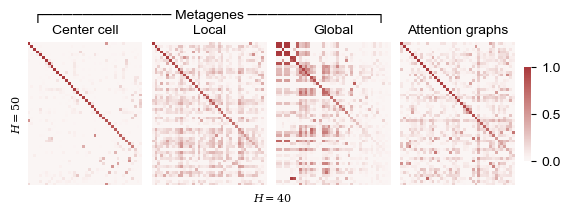

In [6]:
fig = plt.figure(figsize=(6.5, 2))
gs = GridSpec(1, 5, width_ratios=[1.6, 1.6, 1.6, 1.6, 0.1], wspace=.1, figure=fig)
axes = ([fig.add_subplot(gs[0, i]) for i in range(4)])
cbar_ax = fig.add_subplot(gs[0, 4])

#############
ax = axes[0]
corr_df = pd.read_csv('saved_results/mmbrain_q_h40_h50_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Center cell', fontsize=10)
ax.set_ylabel('$H=50$', fontsize=8)
#############
ax = axes[1]
corr_df = pd.read_csv('saved_results/mmbrain_k_h40_h50_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('┌───────────── Metagenes ─────────────┐\nLocal', fontsize=10)

#############
ax = axes[2]
corr_df = pd.read_csv('saved_results/mmbrain_g_h40_h50_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Global', fontsize=10)
ax.set_xlabel('$H=40$' + ' ' * 40, fontsize=8)

#############
ax = axes[3]
corr_df = pd.read_csv('saved_results/mmbrain_s_h40_h50_correlation_reordered.csv', index_col=0)
sns.heatmap(corr_df, xticklabels=False, yticklabels=False, cmap='vlag', center=0.0, vmax=1., vmin=0.0, cbar_ax=cbar_ax, square=True, ax=ax)
ax.set_title('Attention graphs', fontsize=10)

##############################
cbar_ax_position = cbar_ax.get_position()
cbar_ax_position.y0 += 0.15
cbar_ax_position.y1 -= 0.15
# cbar_ax_position.x0 -= 0.01
# cbar_ax_position.x1 -= 0.01
cbar_ax.set_position(cbar_ax_position)

fig.savefig('figures/Ex2_mouse_brain_h_ablation.pdf', **pltkw)